# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
 df = pd.read_csv('data/AviationData_Cleaned.csv',low_memory = False)


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
small = df[df['Total.On.Board'] <= 20]
large = df[df['Total.On.Board'] > 20]
print(f"Small aircraft accidents: {small.shape[0]}")
print(f"Large aircraft accidents: {large.shape[0]}")



Small aircraft accidents: 17006
Large aircraft accidents: 873


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

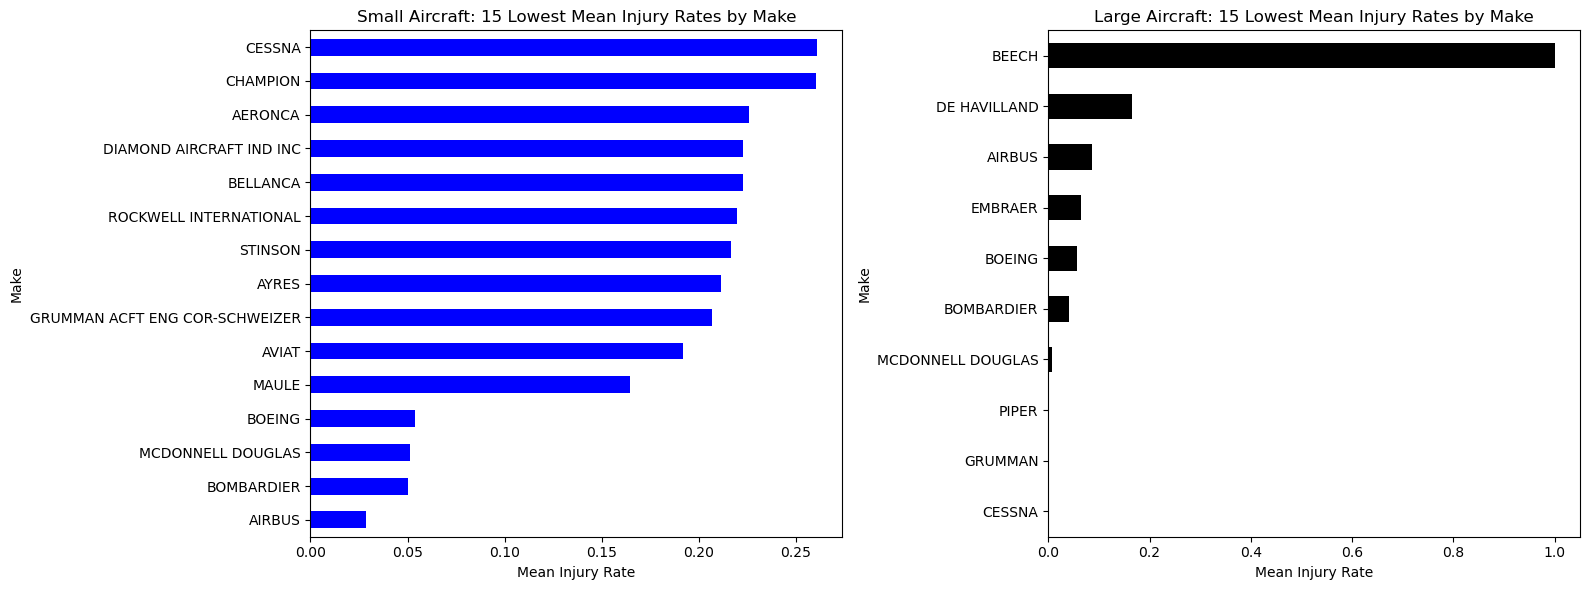

In [5]:
small_makes = small.groupby('Make')['Injury.Rate']. mean().sort_values()
large_makes = large.groupby('Make')['Injury.Rate'].mean().sort_values()
small_top15 = small_makes.head(15)
large_top15 = large_makes.head(15)
fig, axes = plt.subplots(1,2, figsize = (16 ,6))
small_top15.plot(kind = 'barh' ,ax = axes[0],color ='blue')
axes[0].set_title('Small Aircraft: 15 Lowest Mean Injury Rates by Make')
axes[0].set_xlabel('Mean Injury Rate')
large_top15.plot(kind = 'barh', ax = axes[1] ,color = 'black')
axes[1].set_title('Large Aircraft: 15 Lowest Mean Injury Rates by Make')
axes[1].set_xlabel('Mean Injury Rate')
plt.tight_layout()
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

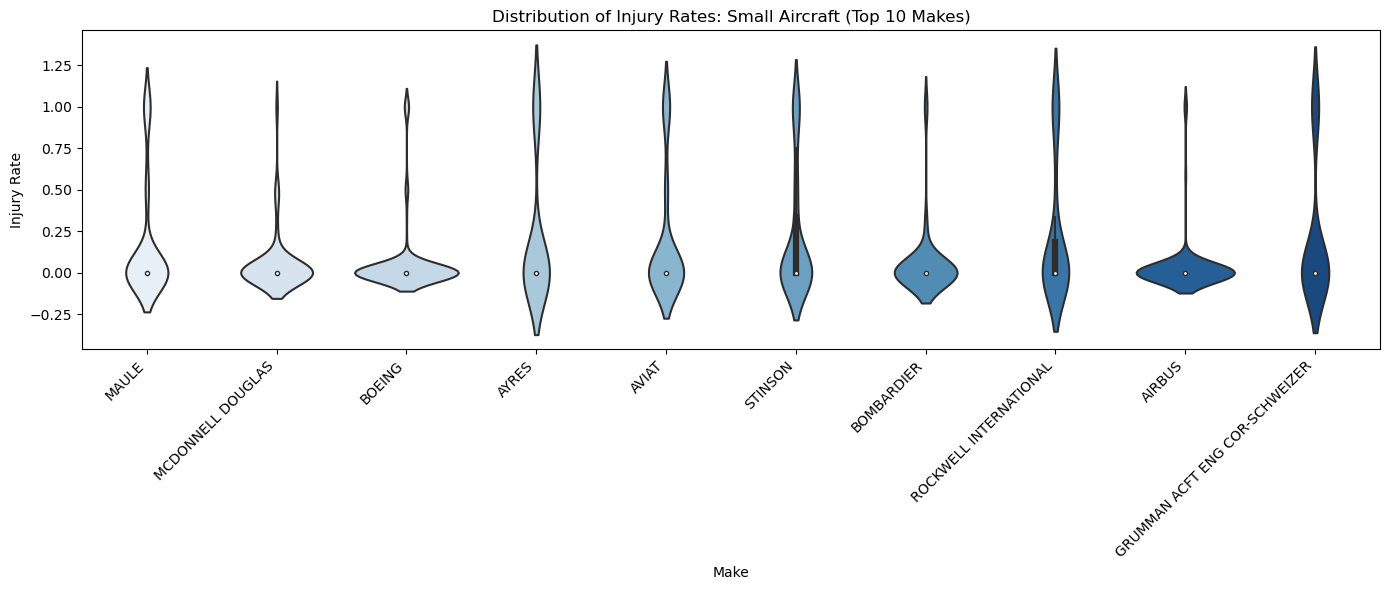

In [6]:

small_top10_makes = small_makes.head(10).index
small_top10 = small[small['Make'].isin(small_top10_makes)]
plt.figure(figsize =(14,6))
sns.violinplot(data = small_top10 , x='Make' , y='Injury.Rate' ,palette ='Blues')
plt.title('Distribution of Injury Rates: Small Aircraft (Top 10 Makes)')
plt.xlabel('Make')
plt.ylabel('Injury Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()








**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24648\683597970.py:2: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=large,x='Make',y='Injury.Rate',palette='Reds')#jitter =True,legend=False)hue='Make
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


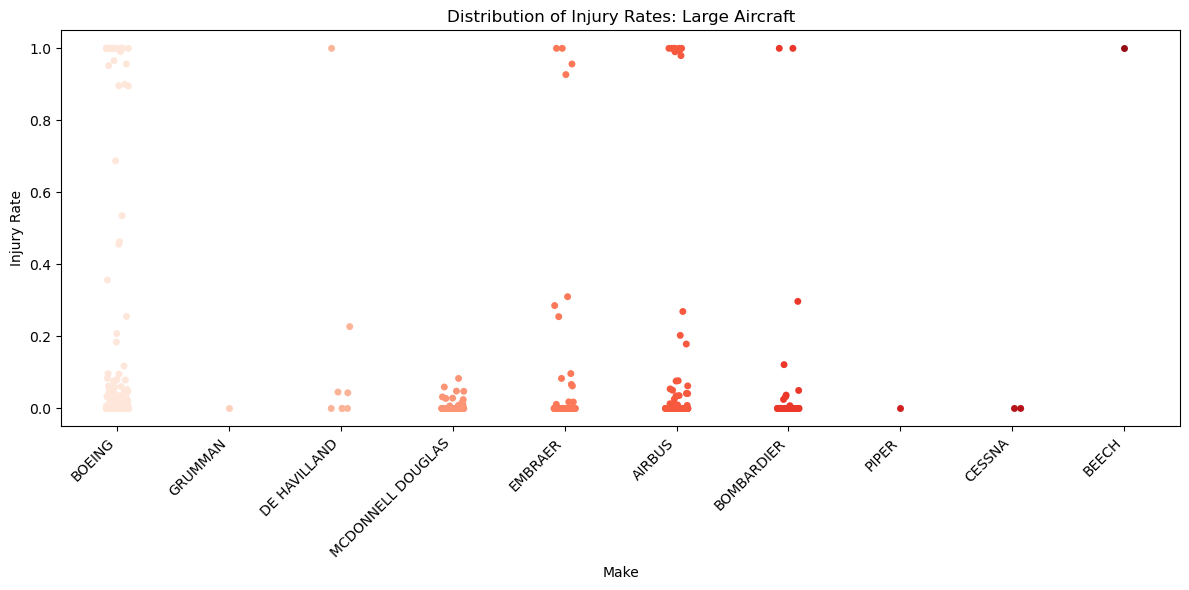

In [15]:
plt .figure(figsize=(12,6))
sns.stripplot(data=large,x='Make',y='Injury.Rate',palette='Reds')#jitter =True,legend=False)hue='Make

plt.title('Distribution of Injury Rates: Large Aircraft')
plt.xlabel('Make')
plt.ylabel('Injury Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

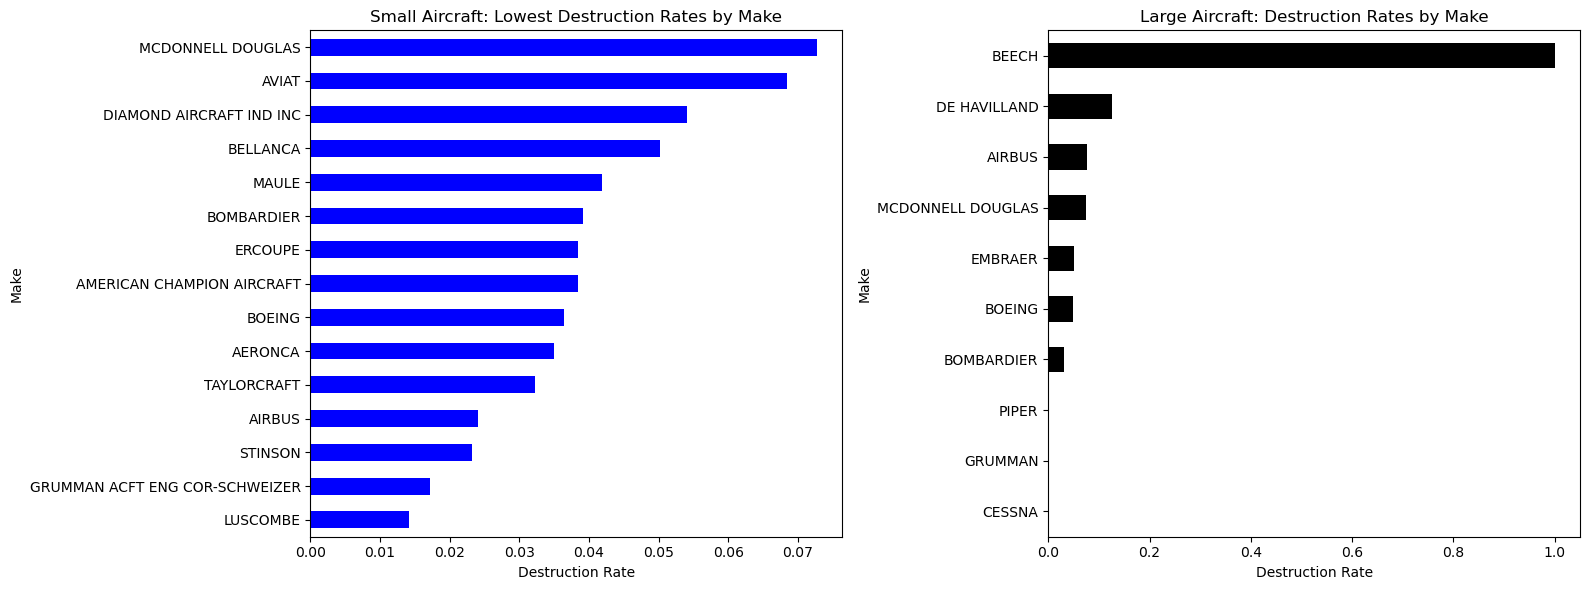

In [16]:
small_dest = small.groupby('Make')['Is_Destroyed'].mean().sort_values().head(15)
large_dest = large.groupby('Make')['Is_Destroyed'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

small_dest.plot(kind='barh', ax=axes[0], color='blue')
axes[0].set_title('Small Aircraft: Lowest Destruction Rates by Make')
axes[0].set_xlabel('Destruction Rate')

large_dest.plot(kind='barh', ax=axes[1], color='black')
axes[1].set_title('Large Aircraft: Destruction Rates by Make')
axes[1].set_xlabel('Destruction Rate')

plt.tight_layout()
plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Findings: Safety by Make

Small Aircraft:
Analysis of small aircraft makes reveals that AIRBUS, BOMBARDIER, and MCDONNELL DOUGLAS 
have the lowest mean injury rates, all close to 0.0. The violin plot confirms that most 
accidents for these makes result in zero serious or fatal injuries, with only rare 
extreme cases reaching a rate of 1.0.

For destruction rate, the top performing small aircraft makes include AIRBUS, BOEING, 
and MCDONNELL DOUGLAS with the lowest rates of total aircraft destruction.

Recommendation for Small Aircraft:
We recommend AIRBUS and MCDONNELL DOUGLAS as the safest small aircraft makes ,
they consistently show low injury rates AND low destruction rates across a 
statistically robust sample of accidents.

Large Aircraft:
Among large aircraft makes, CESSNA, GRUMMAN, and PIPER show the lowest mean 
injury rates. The strip plot shows most accidents for these makes cluster near 0, 
indicating passengers are rarely seriously hurt.

BEECH shows a mean injury rate close to 1.0 but this is based on very few accidents 
and should be interpreted with caution , it is not statistically robust.

Recommendation for Large Aircraft:
We recommend BOEING and MCDONNELL DOUGLAS for large aircraft , they have the 
largest sample sizes, low injury rates, and low destruction rates, making their 
statistics the most reliable.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

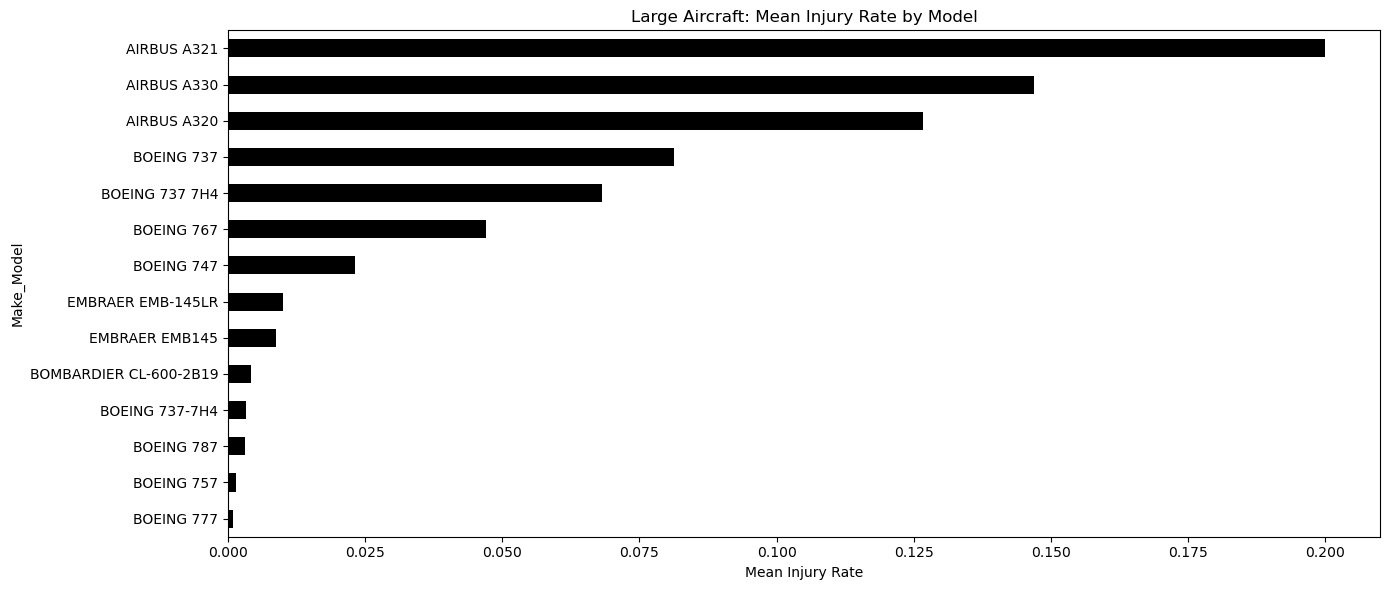

In [19]:
large_model_counts = large.groupby('Make_Model')['Injury.Rate'].count()
large_valid_models = large_model_counts[large_model_counts >= 10].index
large_models = large[large['Make_Model'].isin(large_valid_models)]
large_model_injury = large_models.groupby('Make_Model')['Injury.Rate'].mean().sort_values()
plt.figure(figsize=(14, 6))
large_model_injury.plot(kind='barh', color='black')
plt.title('Large Aircraft: Mean Injury Rate by Model')
plt.xlabel('Mean Injury Rate')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

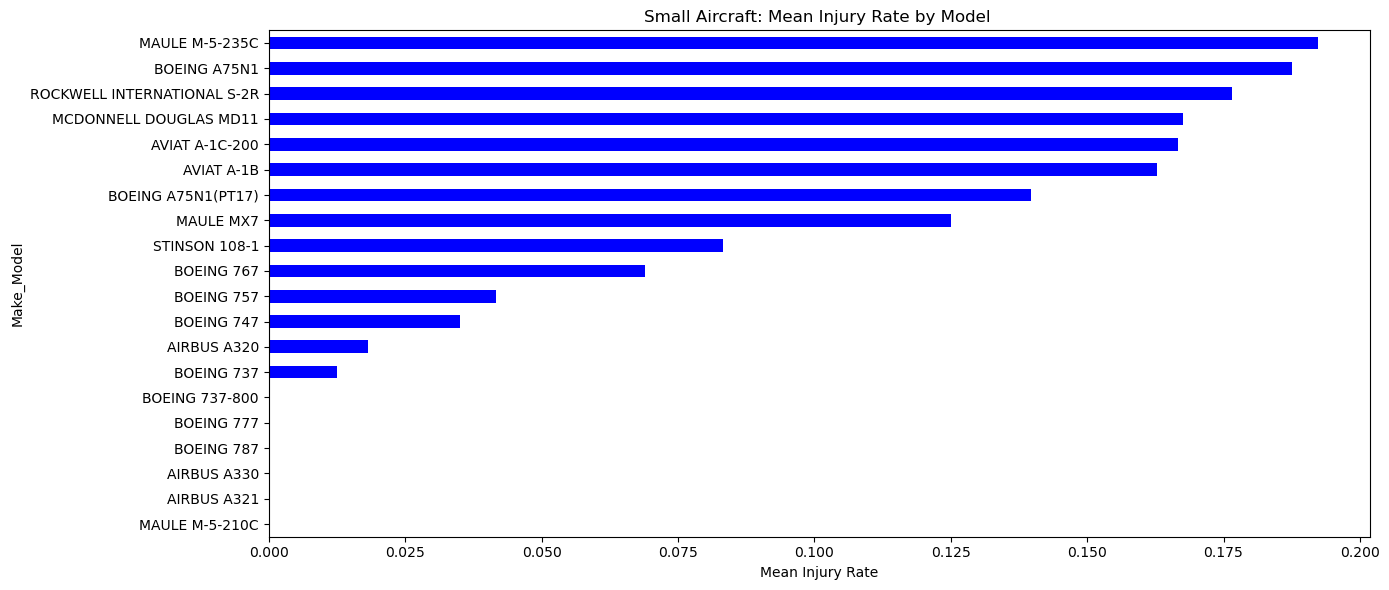

In [20]:
small_model_counts = small.groupby('Make_Model')['Injury.Rate'].count()
small_valid_models = small_model_counts[small_model_counts >= 10].index
small_models = small[small['Make_Model'].isin(small_valid_models)]
small_top10_makes = small.groupby('Make')['Injury.Rate'].mean().sort_values().head(10).index
small_models_filtered = small_models[small_models['Make'].isin(small_top10_makes)]
small_model_injury = small_models_filtered.groupby('Make_Model')['Injury.Rate'].mean().sort_values().head(20)
plt.figure(figsize=(14, 6))
small_model_injury.plot(kind='barh', color='blue')
plt.title('Small Aircraft: Mean Injury Rate by Model ')
plt.xlabel('Mean Injury Rate')
plt.tight_layout()
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Findings: Safety by Specific Model

Large Aircraft Models:
Among large aircraft models with at least 10 recorded accidents, BOEING 737 and 
BOEING 777 stand out with the lowest mean injury rates close to 0.0. This means 
that in the vast majority of accidents involving these models, passengers walk away 
unharmed or with minor injuries only.

AIRBUS A321 shows a higher mean injury rate of approximately 0.2, suggesting a 
higher likelihood of serious or fatal injuries in the event of an accident compared 
to Boeing models.

Recommendation for Large Aircraft Models:
BOEING 737 and BOEING 777 are the top recommendations for large passenger aircraft 
,they have strong safety records backed by large accident sample sizes, making 
these findings statistically reliable.

Small Aircraft Models:
Among small aircraft models, most have mean injury rates close to 0.0. However 
there is notable variation, MAULE M-5 235C shows a higher mean injury rate of 
0.2 while CESSNA 172 and PIPER PA-28 series models consistently show near zero 
injury rates across hundreds of recorded accidents.

Recommendation for Small Aircraft Models:
CESSNA 172 is the top recommendation for small aircraft , it has the largest 
sample size of any model in the dataset and consistently low injury and 
destruction rates, making it the most statistically reliable safe choice.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

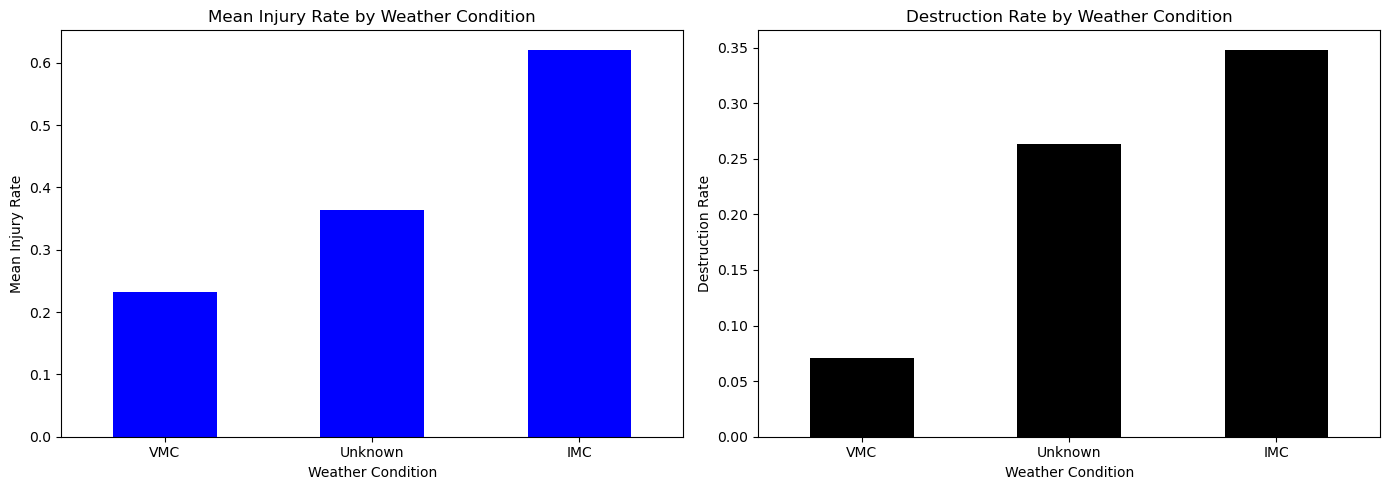

                   Injury.Rate  Is_Destroyed
Weather.Condition                           
IMC                      0.621         0.348
Unknown                  0.364         0.263
VMC                      0.232         0.071


In [18]:
weather_injury = df.groupby('Weather.Condition')['Injury.Rate'].mean().sort_values()
weather_dest = df.groupby('Weather.Condition')['Is_Destroyed'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_injury.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Mean Injury Rate by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Mean Injury Rate')
axes[0].tick_params(axis='x', rotation=0)

weather_dest.plot(kind='bar', ax=axes[1], color='black')
axes[1].set_title('Destruction Rate by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Destruction Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Summary statistics
print(df.groupby('Weather.Condition')[['Injury.Rate', 'Is_Destroyed']].mean().round(3))

In [12]:
#IMC weather condition has the highest mean of injury rate as well as destruction rate

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24648\1115631788.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  engines_df['Number.of.Engines'] = engines_df['Number.of.Engines'].astype(int).astype(str)


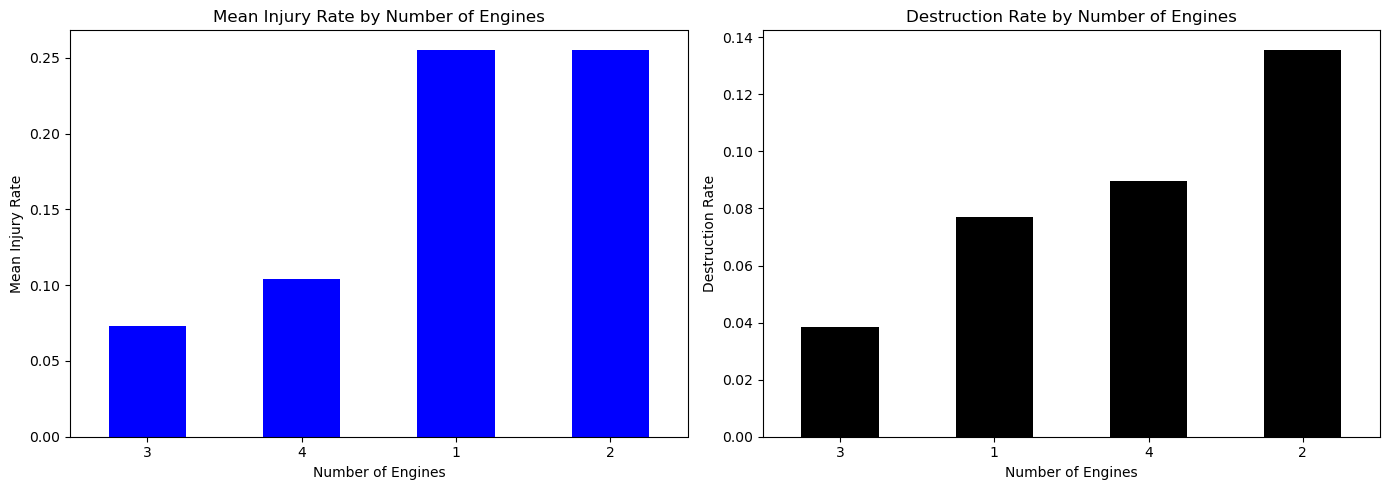

                   Injury.Rate  Is_Destroyed
Number.of.Engines                           
1                        0.255         0.077
2                        0.255         0.136
3                        0.073         0.038
4                        0.104         0.090


In [21]:
engines_df = df.dropna(subset=['Number.of.Engines'])
engines_df['Number.of.Engines'] = engines_df['Number.of.Engines'].astype(int).astype(str)

engine_injury = engines_df.groupby('Number.of.Engines')['Injury.Rate'].mean().sort_values()
engine_dest = engines_df.groupby('Number.of.Engines')['Is_Destroyed'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

engine_injury.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Mean Injury Rate by Number of Engines')
axes[0].set_xlabel('Number of Engines')
axes[0].set_ylabel('Mean Injury Rate')
axes[0].tick_params(axis='x', rotation=0)

engine_dest.plot(kind='bar', ax=axes[1], color='black')
axes[1].set_title('Destruction Rate by Number of Engines')
axes[1].set_xlabel('Number of Engines')
axes[1].set_ylabel('Destruction Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Summary statistics
print(engines_df.groupby('Number.of.Engines')[['Injury.Rate', 'Is_Destroyed']].mean().round(3))

### Factor 1: Weather Condition

It can be said from the study that weather conditions affect both the injury rate 
and destruction rate.
For example, IMC (Instrument Meteorological Conditions, poor visibility, fog) 
presents significantly higher injury rates and destruction rates than VMC (Visual 
Meteorological Conditions, clear weather).

It makes sense since pilots flying in poor visibility conditions are less likely 
to know the surroundings, resulting in greater accidents severity.

Implication for insurers: Accidents happening in IMC condition can be regarded 
as high-risk events. Aircraft makes/models often used in such conditions might be 
considered a high premium risk.


### Factor 2: Number of Engines

Single engine aircraft demonstrates significantly higher rates of both injuries 
and destruction than multi-engine aircraft. It is normal since when a single engine 
fails, there are no additional engines to compensate.

2 engines aircraft present moderate levels while aircraft with 3 or 4 engines have 
the lowest rates of injuries and destruction.

Implication for insurers: Multi-engine aircraft, especially two and above, poses 
less threat to passengers and aircraft. Single engine aircraft can be seen as a 
high-risk object.